In [1]:
import pandas as pd
import os
import numpy as np
import nltk
import zipfile
import os
from bs4 import BeautifulSoup
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

In [2]:
from google.colab import files
uploaded = files.upload()

Saving UpdatedResumeDataSet Optimizing Curriculum Vitae Concordance.csv to UpdatedResumeDataSet Optimizing Curriculum Vitae Concordance.csv


In [3]:
df = pd.read_csv('UpdatedResumeDataSet Optimizing Curriculum Vitae Concordance.csv')

In [4]:
df

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."
...,...,...
957,Testing,Computer Skills: â¢ Proficient in MS office (...
958,Testing,â Willingness to accept the challenges. â ...
959,Testing,"PERSONAL SKILLS â¢ Quick learner, â¢ Eagerne..."
960,Testing,COMPUTER SKILLS & SOFTWARE KNOWLEDGE MS-Power ...


In [5]:
!pip install --upgrade scipy

In [6]:
# Download necessary NLTK resources (only need to run once)
nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [7]:
def preprocess_text(text):
    """
    Preprocesses a given text string for NLP tasks. This includes cleaning the text,
    tokenizing, removing stopwords, and lemmatizing the words.

    Args:
    text (str): The text string to preprocess.

    Returns:
    str: The preprocessed text.
    """
    if not isinstance(text, str):  # Safeguard against non-string input like NaN
        return ""

     # 1. Add spaces around tags, then remove them
    text = re.sub(r'<[^>]+>', ' ', text)

    # 2. Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # 3. Remove emails
    text = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', '', text)

    # 4. Remove special characters (keep only words and whitespace)
    text = re.sub(r'[^\w\s]', '', text)

    #5 Trip out all non-ASCII characters like â, €, ™, etc., that appear due to encoding mismatches
    text = text.encode('ascii', 'ignore').decode()

    text = text.lower()

    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    filtered_tokens = [word for word in tokens if word not in stop_words]

    lemmatizer = WordNetLemmatizer()
    lemmatized_text = [lemmatizer.lemmatize(word) for word in filtered_tokens]

    return ' '.join(lemmatized_text)

In [8]:
# Apply preprocessing
# Keep original resume text in a new column
df['Resume_original'] = df['Resume']

# Apply preprocessing only on 'Resume'
df['Resume'] = df['Resume'].apply(preprocess_text)


In [9]:
df

,Category,Resume,Resume_original
0,Data Science,skill programming language python panda numpy ...,Skills * Programming Languages: Python (pandas...
1,Data Science,education detail may 2013 may 2017 uitrgpv dat...,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,area interest deep learning control system des...,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,skill r python sap hana tableau sap hana sql s...,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,education detail mca ymcaust faridabad haryana...,"Education Details \r\n MCA YMCAUST, Faridab..."
...,...,...,...
957,Testing,computer skill proficient m office word basic ...,Computer Skills: â¢ Proficient in MS office (...
958,Testing,willingness accept challenge positive thinking...,â Willingness to accept the challenges. â ...
959,Testing,personal skill quick learner eagerness learn n...,"PERSONAL SKILLS â¢ Quick learner, â¢ Eagerne..."
960,Testing,computer skill software knowledge mspower poin...,COMPUTER SKILLS & SOFTWARE KNOWLEDGE MS-Power ...


In [10]:
def drop_duplicates(df, column_name):
    """
    Drops duplicates based on a specified column from the DataFrame.

    Args:
    df (pd.DataFrame): The DataFrame from which to remove duplicates.
    column_name (str): The name of the column based on which duplicates will be identified.

    Returns:
    pd.DataFrame: DataFrame with duplicates removed based on the specified column.
    """
    if column_name not in df.columns:
        raise ValueError(f"Column '{column_name}' not found in DataFrame")

    original_size = df.shape[0]
    df_cleaned = df.drop_duplicates(subset=[column_name])
    new_size = df_cleaned.shape[0]

    print(f"Dropped {original_size - new_size} duplicates from '{column_name}'. New dataset size: {new_size}")

    return df_cleaned

In [11]:
df = drop_duplicates(df, column_name='Resume')

Dropped 796 duplicates from 'Resume'. New dataset size: 166


In [12]:
#resume_df_final = df[['Resume']].rename(columns={'Resume': 'resume_summary'})
#resume_df_final = df[['Resume', 'Resume_original']].rename(columns={'Resume': 'resume_summary'})
#resume_df_final = df[['Resume', 'Resume_original', 'Category']].rename(columns={'Resume': 'resume_summary'})
resume_df_final = df[['Resume', 'Resume_original', 'Category']].rename(columns={'Resume': 'resume_summary','Category': 'Category_original'})
jobs_df_final = df[['Category']].rename(columns={'Category': 'job_summary'})

In [13]:
resume_df_final

,resume_summary,Resume_original,Category_original
0,skill programming language python panda numpy ...,Skills * Programming Languages: Python (pandas...,Data Science
1,education detail may 2013 may 2017 uitrgpv dat...,Education Details \r\nMay 2013 to May 2017 B.E...,Data Science
2,area interest deep learning control system des...,"Areas of Interest Deep Learning, Control Syste...",Data Science
3,skill r python sap hana tableau sap hana sql s...,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...,Data Science
4,education detail mca ymcaust faridabad haryana...,"Education Details \r\n MCA YMCAUST, Faridab...",Data Science
...,...,...,...
894,computer skill proficient m office word basic ...,Computer Skills: â¢ Proficient in MS office (...,Testing
895,willingness accept challenge positive thinking...,â Willingness to accept the challenges. â ...,Testing
896,personal skill quick learner eagerness learn n...,"PERSONAL SKILLS â¢ Quick learner, â¢ Eagerne...",Testing
897,computer skill software knowledge mspower poin...,COMPUTER SKILLS & SOFTWARE KNOWLEDGE MS-Power ...,Testing


In [14]:
jobs_df_final

,job_summary
0,Data Science
1,Data Science
2,Data Science
3,Data Science
4,Data Science
...,...
894,Testing
895,Testing
896,Testing
897,Testing


In [15]:
!pip install -U sentence-transformers

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import confusion_matrix

class SentenceTransformerEncoder:
    def __init__(self, model_name='all-MiniLM-L6-v2'):
        self.model = SentenceTransformer(model_name)

    def encode_column(self, df, column, batch_size=32, encoded_column_suffix='_encoded'):
        if column not in df.columns:
            raise ValueError(f"Column '{column}' not found in DataFrame")

        encoded_vectors = []
        for start_idx in range(0, len(df), batch_size):
            end_idx = min(start_idx + batch_size, len(df))
            batch_texts = df[column][start_idx:end_idx].tolist()
            batch_encoded = self.model.encode(batch_texts, show_progress_bar=True)
            encoded_vectors.extend(batch_encoded)

        df[column + encoded_column_suffix] = encoded_vectors
        return df


In [17]:
def split_df(df, train_frac=0.8, val_frac=0.1, random_state=42):
    df_shuffled = df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    n = len(df_shuffled)
    train_end = int(n * train_frac)
    val_end = int(n * (train_frac + val_frac))

    train_df = df_shuffled.iloc[:train_end].reset_index(drop=True)
    val_df = df_shuffled.iloc[train_end:val_end].reset_index(drop=True)
    test_df = df_shuffled.iloc[val_end:].reset_index(drop=True)

    return train_df, val_df, test_df

In [18]:
# --- Perform evaluation for one run ---
def perform_evaluation_run(resume_df, jobs_df, model_name='sentence-t5-base', random_seed=42):
    # Split data
    resume_train, resume_val, resume_test = split_df(resume_df, random_state=random_seed)
    jobs_train, jobs_val, jobs_test = split_df(jobs_df, random_state=random_seed)

    # Encode datasets
    encoder = SentenceTransformerEncoder(model_name=model_name)
    resume_test = encoder.encode_column(resume_test, 'resume_summary')
    jobs_test = encoder.encode_column(jobs_test, 'job_summary')

    # Extract embeddings
    resume_test_embeds = np.vstack(resume_test['resume_summary_encoded'].values)
    jobs_test_embeds = np.vstack(jobs_test['job_summary_encoded'].values)

    # Compute similarity matrix
    similarity_matrix = cosine_similarity(resume_test_embeds, jobs_test_embeds)

    # Collect all matches
    results = []
    for r_idx in range(similarity_matrix.shape[0]):
        for j_idx in range(similarity_matrix.shape[1]):
            score = similarity_matrix[r_idx, j_idx]
            results.append({
                'resume_index': r_idx,
                'job_index': j_idx,
                'similarity_score': score,
                'resume_summary': resume_test.iloc[r_idx]['resume_summary'],
                'resume_original': resume_test.iloc[r_idx]['Resume_original'],
                'category_original': resume_test.iloc[r_idx]['Category_original'],
                'job_summary': jobs_test.iloc[j_idx]['job_summary']
            })

    matches_df = pd.DataFrame(results)

    # Highest similarity among wrong matches
    wrong_matches = matches_df[matches_df['category_original'] != matches_df['job_summary']]
    dynamic_threshold = wrong_matches['similarity_score'].max()

    # Define is_correct using dynamic threshold
    matches_df['is_correct'] = matches_df['similarity_score'] > dynamic_threshold

    # Metrics
    metrics = {
        'avg_similarity': matches_df['similarity_score'].mean(),
        'median_similarity': matches_df['similarity_score'].median(),
        'std_similarity': matches_df['similarity_score'].std(),
        'accuracy': matches_df['is_correct'].mean(),
        'num_matches': len(matches_df),
        'num_correct_matches': matches_df['is_correct'].sum(),
        'pct_correct_matches': matches_df['is_correct'].mean() * 100,
        'highest_wrong_similarity': dynamic_threshold
    }

    return metrics, matches_df

In [19]:
# --- Run multiple evaluations ---
def run_multiple_evaluations(resume_df, jobs_df, model_name='sentence-t5-base', num_runs=5):
    all_metrics = []
    all_matches_dfs = []
    all_similarity_scores = []
    all_accuracy_scores = []

    for run in tqdm(range(num_runs), desc="Running Evaluations"):
        random_seed = 42 + run
        metrics, matches_df = perform_evaluation_run(
            resume_df, jobs_df, model_name, random_seed
        )

        metrics['run'] = run + 1
        matches_df['run'] = run + 1

        all_metrics.append(metrics)
        all_matches_dfs.append(matches_df)
        all_similarity_scores.append(metrics['avg_similarity'])
        all_accuracy_scores.append(metrics['pct_correct_matches'])

    metrics_df = pd.DataFrame(all_metrics)
    combined_df = pd.concat(all_matches_dfs)

    # Dynamic threshold across runs
    dynamic_threshold = metrics_df['highest_wrong_similarity'].mean()
    print(f"\nDynamic similarity threshold (average of highest wrong matches per run): {dynamic_threshold:.3f}")

    # --- Visualization ---
    plt.figure(figsize=(15, 10))

    # 1. Avg similarity per run
    plt.subplot(2,2,1)
    plt.bar(range(1, num_runs + 1), all_similarity_scores)
    plt.axhline(y=np.mean(all_similarity_scores), color='r', linestyle='-')
    plt.xlabel('Run Number')
    plt.ylabel('Average Similarity Score')
    plt.title('Similarity Scores Across Runs')
    plt.grid(True, alpha=0.3)

    # 2. Distribution of similarity scores
    plt.subplot(2,2,2)
    sns.histplot(combined_df['similarity_score'], bins=30, kde=True)
    plt.axvline(x=dynamic_threshold, color='r', linestyle='--', label=f'Dynamic Threshold: {dynamic_threshold:.3f}')
    plt.axvline(x=np.mean(all_similarity_scores), color='g', linestyle='-', label=f'Mean: {np.mean(all_similarity_scores):.3f}')
    plt.xlabel('Similarity Score')
    plt.ylabel('Frequency')
    plt.title('Distribution of All Similarity Scores')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # 3. Heatmap (sample)
    plt.subplot(2,2,3)
    sample_size = min(50, len(resume_df))
    pivot_df = combined_df[combined_df['run'] == 1].iloc[:sample_size*sample_size]
    pivot_matrix = pivot_df.pivot_table(
        index='resume_index',
        columns='job_index',
        values='similarity_score',
        aggfunc='mean'
    ).iloc[:sample_size, :sample_size]
    sns.heatmap(pivot_matrix, cmap='viridis', vmin=0, vmax=1)
    plt.title(f'Similarity Heatmap (Sample of {sample_size}x{sample_size})')
    plt.xlabel('Job Index')
    plt.ylabel('Resume Index')

    # 4. Accuracy per run
    plt.subplot(2,2,4)
    plt.bar(range(1, num_runs + 1), all_accuracy_scores)
    plt.axhline(y=np.mean(all_accuracy_scores), color='r', linestyle='-')
    plt.xlabel('Run Number')
    plt.ylabel('Percentage of Correct Matches')
    plt.title('Accuracy Across Runs')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # --- High/Low examples ---
    print("\n=== EXAMPLES OF HIGH SIMILARITY MATCHES ===")
    high_sim = combined_df.sort_values('similarity_score', ascending=False).head(3)
    for i, row in high_sim.iterrows():
        print(f"\nSimilarity Score: {row['similarity_score']:.3f}")
        print(f"Resume (processed): {row['resume_summary'][:100]}...")
        print(f"Resume (before preprocessing): {row['resume_original'][:100]}...")
        print(f"Job Category (annotated): {row['category_original']}")
        print(f"Predicted Job category: {row['job_summary'][:100]}...")
        print("-"*50)

    print("\n=== EXAMPLES OF LOW SIMILARITY MATCHES ===")
    low_sim = combined_df.sort_values('similarity_score').head(3)
    for i, row in low_sim.iterrows():
        print(f"\nSimilarity Score: {row['similarity_score']:.3f}")
        print(f"Resume (processed): {row['resume_summary'][:100]}...")
        print(f"Resume (before preprocessing): {row['resume_original'][:100]}...")
        print(f"Job Category (annotated): {row['category_original']}")
        print(f"Predicted Job category: {row['job_summary'][:100]}...")
        print("-"*50)

    # Percentiles
    percentiles = [10, 25, 50, 75, 90, 95, 99]
    score_percentiles = np.percentile(combined_df['similarity_score'], percentiles)
    print("\n=== SIMILARITY SCORE PERCENTILES ===")
    for p, score in zip(percentiles, score_percentiles):
        print(f"{p}th percentile: {score:.3f}")

    # Save results
    combined_df.to_csv('all_similarity_scores.csv', index=False)
    metrics_df.to_csv('evaluation_metrics.csv', index=False)

    print("\n=== EVALUATION COMPLETE ===")
    print(f"Total matches evaluated: {len(combined_df)}")
    print(f"Results saved to CSV files")

    return metrics_df, combined_df


In [20]:
resume_df_final

,resume_summary,Resume_original,Category_original
0,skill programming language python panda numpy ...,Skills * Programming Languages: Python (pandas...,Data Science
1,education detail may 2013 may 2017 uitrgpv dat...,Education Details \r\nMay 2013 to May 2017 B.E...,Data Science
2,area interest deep learning control system des...,"Areas of Interest Deep Learning, Control Syste...",Data Science
3,skill r python sap hana tableau sap hana sql s...,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...,Data Science
4,education detail mca ymcaust faridabad haryana...,"Education Details \r\n MCA YMCAUST, Faridab...",Data Science
...,...,...,...
894,computer skill proficient m office word basic ...,Computer Skills: â¢ Proficient in MS office (...,Testing
895,willingness accept challenge positive thinking...,â Willingness to accept the challenges. â ...,Testing
896,personal skill quick learner eagerness learn n...,"PERSONAL SKILLS â¢ Quick learner, â¢ Eagerne...",Testing
897,computer skill software knowledge mspower poin...,COMPUTER SKILLS & SOFTWARE KNOWLEDGE MS-Power ...,Testing


In [21]:
jobs_df_final

,job_summary
0,Data Science
1,Data Science
2,Data Science
3,Data Science
4,Data Science
...,...
894,Testing
895,Testing
896,Testing
897,Testing


In [22]:
# --- Set parameters ---
model_name = 'sentence-t5-base'  # Or 'paraphrase-mpnet-base-v2'
num_runs = 5

print(f"Starting evaluation with model: {model_name}")
print(f"Running {num_runs} evaluations with dynamic threshold based on highest wrong matches")

# --- Initialize storage for results ---
all_metrics = []
all_matches_dfs = []
all_similarity_scores = []
all_accuracy_scores = []
all_median_similarity_scores = []

# --- Run evaluations ---
for run in tqdm(range(num_runs), desc="Running Evaluations"):
    random_seed = 42 + run

    # Split data with the specific seed
    resume_train, resume_val, resume_test = split_df(resume_df_final, random_state=random_seed)
    jobs_train, jobs_val, jobs_test = split_df(jobs_df_final, random_state=random_seed)

    # Create encoder with the specified model
    encoder = SentenceTransformerEncoder(model_name=model_name)

    # Encode all datasets
    resume_train = encoder.encode_column(resume_train, 'resume_summary')
    resume_val = encoder.encode_column(resume_val, 'resume_summary')
    resume_test = encoder.encode_column(resume_test, 'resume_summary')

    jobs_train = encoder.encode_column(jobs_train, 'job_summary')
    jobs_val = encoder.encode_column(jobs_val, 'job_summary')
    jobs_test = encoder.encode_column(jobs_test, 'job_summary')

    # Extract embeddings as numpy arrays
    resume_test_embeds = np.vstack(resume_test['resume_summary_encoded'].values)
    jobs_test_embeds = np.vstack(jobs_test['job_summary_encoded'].values)

    # Compute similarity matrix
    similarity_matrix = cosine_similarity(resume_test_embeds, jobs_test_embeds)

    # Collect all matches
    results = []
    for resume_idx in range(similarity_matrix.shape[0]):
        for job_idx in range(similarity_matrix.shape[1]):
            score = similarity_matrix[resume_idx, job_idx]
            results.append({
                'resume_index': resume_idx,
                'job_index': job_idx,
                'similarity_score': score,
                'resume_summary': resume_test.iloc[resume_idx]['resume_summary'],
                'resume_original': resume_test.iloc[resume_idx]['Resume_original'],
                'category_original': resume_test.iloc[resume_idx]['Category_original'],
                'job_summary': jobs_test.iloc[job_idx]['job_summary']
            })

    matches_df = pd.DataFrame(results)

    # Determine highest similarity among wrong matches
    wrong_matches = matches_df[matches_df['category_original'] != matches_df['job_summary']]
    highest_wrong_similarity = wrong_matches['similarity_score'].max()

    # Define is_correct using dynamic threshold
    matches_df['is_correct'] = matches_df['similarity_score'] > highest_wrong_similarity

    # Calculate metrics for this run
    run_metrics = {
        'avg_similarity': matches_df['similarity_score'].mean(),
        'median_similarity': matches_df['similarity_score'].median(),
        'std_similarity': matches_df['similarity_score'].std(),
        'accuracy': matches_df['is_correct'].mean(),
        'num_matches': len(matches_df),
        'num_correct_matches': matches_df['is_correct'].sum(),
        'pct_correct_matches': matches_df['is_correct'].mean() * 100,
        'highest_wrong_similarity': highest_wrong_similarity,
        'run': run + 1
    }

    # Store results for this run
    all_metrics.append(run_metrics)
    matches_df['run'] = run + 1
    all_matches_dfs.append(matches_df)

    # Store specific metrics for plotting
    all_similarity_scores.append(run_metrics['avg_similarity'])
    all_accuracy_scores.append(run_metrics['pct_correct_matches'])
    all_median_similarity_scores.append(run_metrics['median_similarity'])

# --- Combine all results ---
metrics_df = pd.DataFrame(all_metrics)
combined_df = pd.concat(all_matches_dfs)

# --- Compute dynamic threshold across runs ---
dynamic_threshold = metrics_df['highest_wrong_similarity'].mean()
print(f"\nDynamic similarity threshold (average of highest wrong matches per run): {dynamic_threshold:.3f}")

# --- Print summary statistics ---
print("\n=== EVALUATION SUMMARY ===")
print(f"Average similarity: {metrics_df['avg_similarity'].mean():.3f} ± {metrics_df['avg_similarity'].std():.3f}")
print(f"Median similarity: {metrics_df['median_similarity'].mean():.3f}")
print(f"Standard deviation: {metrics_df['std_similarity'].mean():.3f}")
print(f"Average accuracy: {metrics_df['accuracy'].mean():.3f} ± {metrics_df['accuracy'].std():.3f}")
print(f"Average number of matches: {metrics_df['num_matches'].mean():.1f}")
print(f"Average number of correct matches: {metrics_df['num_correct_matches'].mean():.1f}")
print(f"Average percentage of correct matches: {metrics_df['pct_correct_matches'].mean():.2f}%")

Starting evaluation with model: sentence-t5-base
Running 5 evaluations with dynamic threshold based on highest wrong matches


Running Evaluations:   0%|          | 0/5 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/461 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Dynamic similarity threshold (average of highest wrong matches per run): 0.831

=== EVALUATION SUMMARY ===
Average similarity: 0.765 ± 0.003
Median similarity: 0.762
Standard deviation: 0.029
Average accuracy: 0.029 ± 0.019
Average number of matches: 289.0
Average number of correct matches: 8.4
Average percentage of correct matches: 2.91%



Dynamic similarity threshold (average of highest wrong matches per run): 0.831


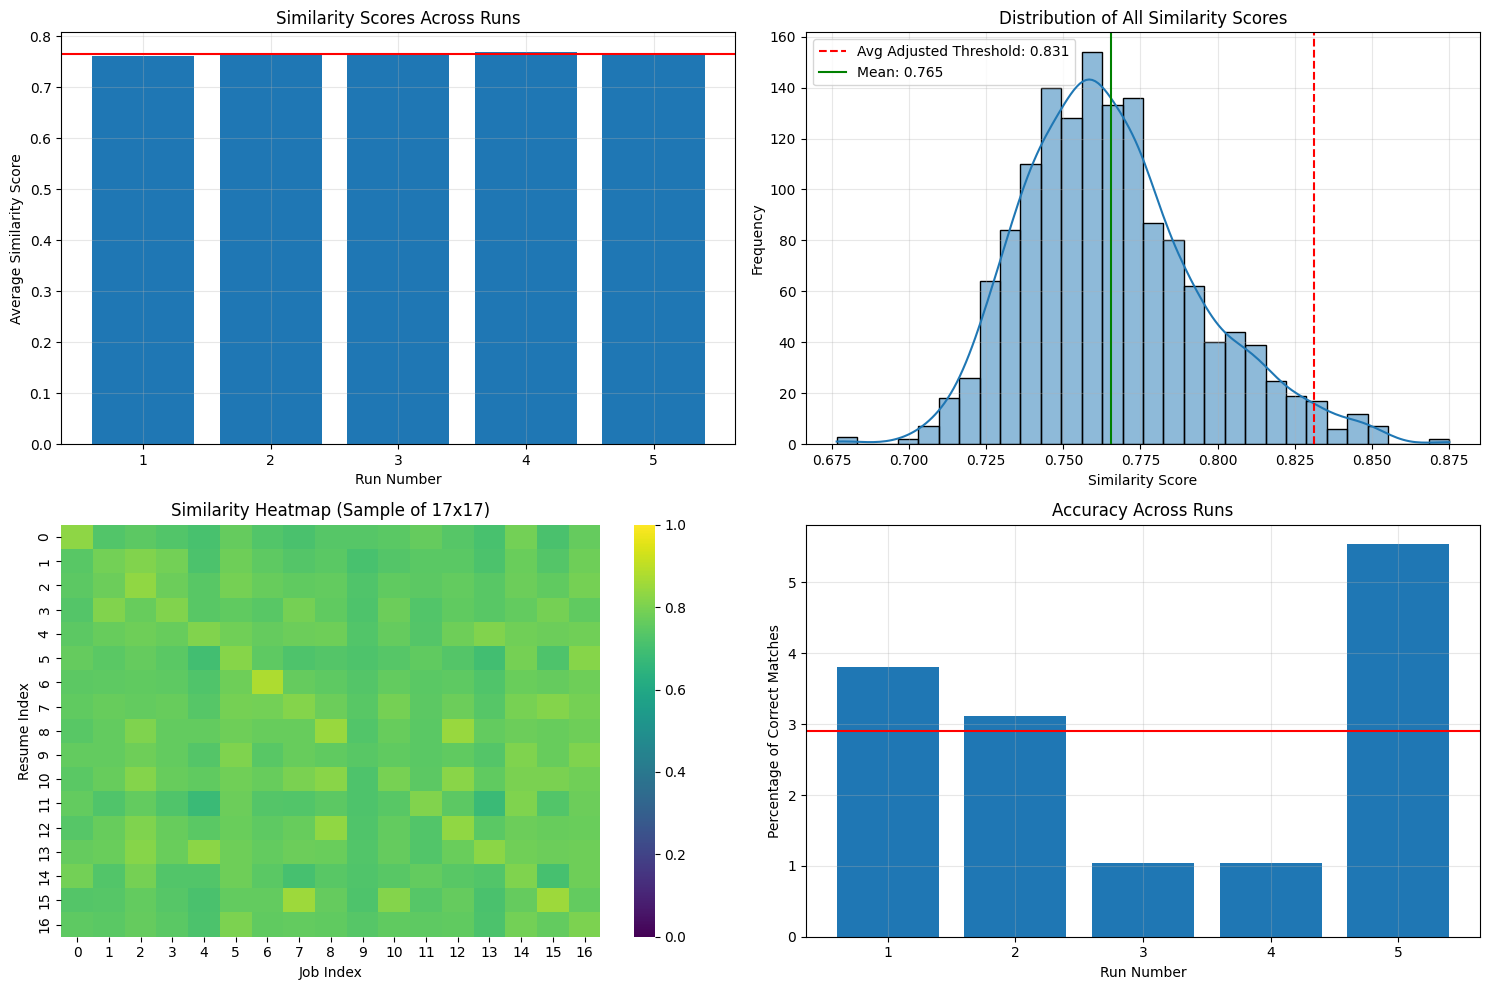


=== EXAMPLES OF HIGH SIMILARITY MATCHES ===

Similarity Score: 0.875
Resume (processed): skill set experience implementing troubleshooting network security solution planning implementation ...
Resume (before preprocessing): Skill Set â¢ Experience in Implementing, and troubleshooting network security solutions â¢ Plannin...
Job Category (annotated): Network Security Engineer
Predicted Job category: Network Security Engineer...
--------------------------------------------------

Similarity Score: 0.875
Resume (processed): skill set experience implementing troubleshooting network security solution planning implementation ...
Resume (before preprocessing): Skill Set â¢ Experience in Implementing, and troubleshooting network security solutions â¢ Plannin...
Job Category (annotated): Network Security Engineer
Predicted Job category: Network Security Engineer...
--------------------------------------------------

Similarity Score: 0.853
Resume (processed): personal skill ability quickly

In [23]:
# --- Visualization and Summary Reporting with Dynamic Threshold ---
dynamic_threshold = metrics_df['highest_wrong_similarity'].mean()
print(f"\nDynamic similarity threshold (average of highest wrong matches per run): {dynamic_threshold:.3f}")

# Create visualizations
plt.figure(figsize=(15, 10))

# Plot 1: Average similarity across runs
plt.subplot(2, 2, 1)
plt.bar(range(1, num_runs + 1), all_similarity_scores)
plt.axhline(y=np.mean(all_similarity_scores), color='r', linestyle='-')
plt.xlabel('Run Number')
plt.ylabel('Average Similarity Score')
plt.title('Similarity Scores Across Runs')
plt.grid(True, alpha=0.3)

# Plot 2: Distribution of similarity scores
plt.subplot(2, 2, 2)
sns.histplot(combined_df['similarity_score'], bins=30, kde=True)
plt.axvline(x=dynamic_threshold, color='r', linestyle='--', label=f'Avg Adjusted Threshold: {dynamic_threshold:.3f}')
plt.axvline(x=np.mean(all_similarity_scores), color='g', linestyle='-', label=f'Mean: {np.mean(all_similarity_scores):.3f}')
plt.xlabel('Similarity Score')
plt.ylabel('Frequency')
plt.title('Distribution of All Similarity Scores')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Heatmap of similarity scores (sample)
plt.subplot(2, 2, 3)
sample_size = min(50, len(resume_test))
pivot_df = combined_df[combined_df['run'] == 1].iloc[:sample_size*sample_size]
pivot_matrix = pivot_df.pivot_table(
    index='resume_index',
    columns='job_index',
    values='similarity_score',
    aggfunc='mean'
).iloc[:sample_size, :sample_size]
sns.heatmap(pivot_matrix, cmap='viridis', vmin=0, vmax=1)
plt.title(f'Similarity Heatmap (Sample of {sample_size}x{sample_size})')
plt.xlabel('Job Index')
plt.ylabel('Resume Index')

# Plot 4: Accuracy across runs
plt.subplot(2, 2, 4)
plt.bar(range(1, num_runs + 1), all_accuracy_scores)
plt.axhline(y=np.mean(all_accuracy_scores), color='r', linestyle='-')
plt.xlabel('Run Number')
plt.ylabel('Percentage of Correct Matches')
plt.title('Accuracy Across Runs')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Show examples of high similarity matches
print("\n=== EXAMPLES OF HIGH SIMILARITY MATCHES ===")
high_sim = combined_df.sort_values('similarity_score', ascending=False).head(3)
for i, row in high_sim.iterrows():
    print(f"\nSimilarity Score: {row['similarity_score']:.3f}")
    print(f"Resume (processed): {row['resume_summary'][:100]}...")
    print(f"Resume (before preprocessing): {row['resume_original'][:100]}...")
    print(f"Job Category (annotated): {row['category_original']}")
    print(f"Predicted Job category: {row['job_summary'][:100]}...")
    print("-" * 50)

# Show examples of low similarity matches
print("\n=== EXAMPLES OF LOW SIMILARITY MATCHES ===")
low_sim = combined_df.sort_values('similarity_score').head(3)
for i, row in low_sim.iterrows():
    print(f"\nSimilarity Score: {row['similarity_score']:.3f}")
    print(f"Resume (processed): {row['resume_summary'][:100]}...")
    print(f"Resume (before processing): {row['resume_original'][:100]}...")
    print(f"Job Category (annotated): {row['category_original']}")
    print(f"Predicted Job category: {row['job_summary'][:100]}...")
    print("-" * 50)

# Additional analysis: Distribution of scores by percentile
percentiles = [10, 25, 50, 75, 90, 95, 99]
score_percentiles = np.percentile(combined_df['similarity_score'], percentiles)

print("\n=== SIMILARITY SCORE PERCENTILES ===")
for p, score in zip(percentiles, score_percentiles):
    print(f"{p}th percentile: {score:.3f}")

# Save results to CSV for further analysis
combined_df.to_csv('all_similarity_scores.csv', index=False)
metrics_df.to_csv('evaluation_metrics.csv', index=False)

print("\n=== EVALUATION COMPLETE ===")
print(f"Total matches evaluated: {len(combined_df)}")
print(f"Results saved to CSV files")

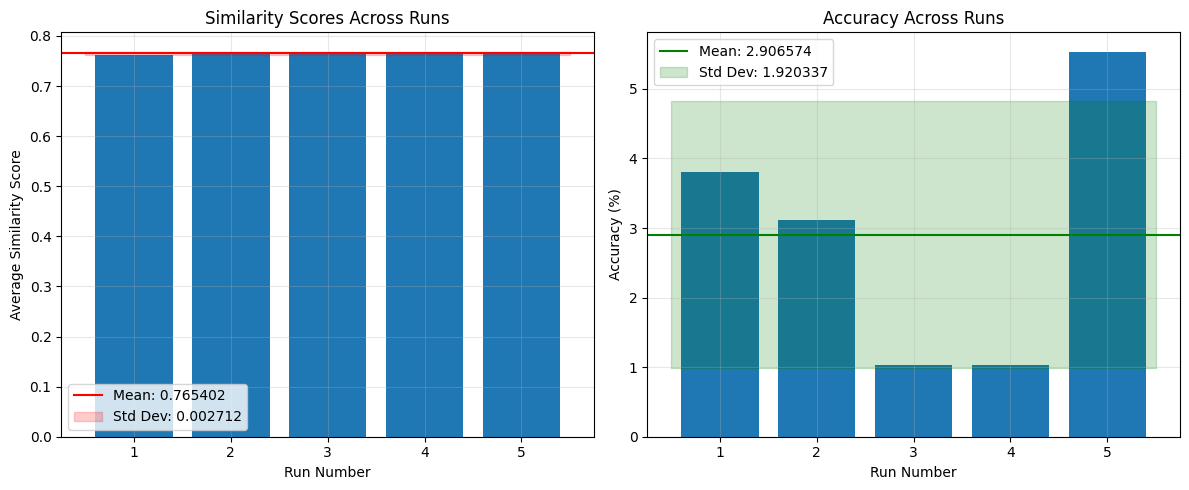

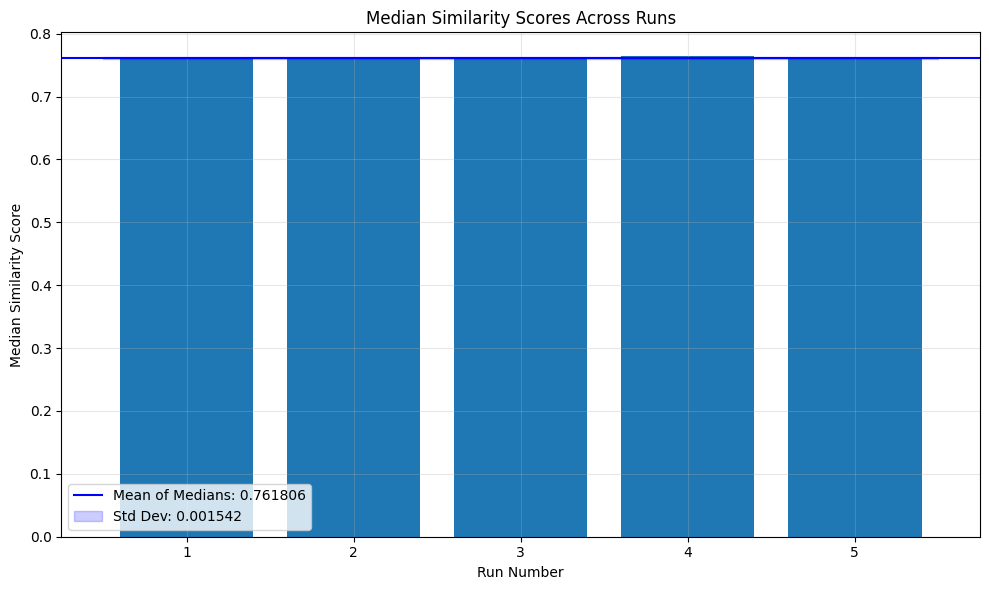

In [24]:
# Plot the similarity results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(metrics_df['run'], metrics_df['avg_similarity'])
plt.axhline(y=metrics_df['avg_similarity'].mean(), color='r', linestyle='-',
            label=f'Mean: {metrics_df["avg_similarity"].mean():.6f}')
plt.fill_between(
    [0.5, len(metrics_df)+0.5],
    [metrics_df['avg_similarity'].mean() - metrics_df['avg_similarity'].std()]*2,
    [metrics_df['avg_similarity'].mean() + metrics_df['avg_similarity'].std()]*2,
    color='r', alpha=0.2, label=f'Std Dev: {metrics_df["avg_similarity"].std():.6f}'
)
plt.xlabel('Run Number')
plt.ylabel('Average Similarity Score')
plt.title('Similarity Scores Across Runs')
plt.xticks(metrics_df['run'])
plt.legend()
plt.grid(True, alpha=0.3)

# Plot the accuracy results
plt.subplot(1, 2, 2)
plt.bar(metrics_df['run'], metrics_df['pct_correct_matches'])
plt.axhline(y=metrics_df['pct_correct_matches'].mean(), color='g', linestyle='-',
            label=f'Mean: {metrics_df["pct_correct_matches"].mean():.6f}')
plt.fill_between(
    [0.5, len(metrics_df)+0.5],
    [metrics_df['pct_correct_matches'].mean() - metrics_df['pct_correct_matches'].std()]*2,
    [metrics_df['pct_correct_matches'].mean() + metrics_df['pct_correct_matches'].std()]*2,
    color='g', alpha=0.2, label=f'Std Dev: {metrics_df["pct_correct_matches"].std():.6f}'
)
plt.xlabel('Run Number')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Across Runs')
plt.xticks(metrics_df['run'])
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Add a new plot for median similarity scores
plt.figure(figsize=(10, 6))
plt.bar(metrics_df['run'], metrics_df['median_similarity'])
plt.axhline(y=metrics_df['median_similarity'].mean(), color='b', linestyle='-',
            label=f'Mean of Medians: {metrics_df["median_similarity"].mean():.6f}')
plt.fill_between(
    [0.5, len(metrics_df)+0.5],
    [metrics_df['median_similarity'].mean() - metrics_df['median_similarity'].std()]*2,
    [metrics_df['median_similarity'].mean() + metrics_df['median_similarity'].std()]*2,
    color='b', alpha=0.2, label=f'Std Dev: {metrics_df["median_similarity"].std():.6f}'
)
plt.xlabel('Run Number')
plt.ylabel('Median Similarity Score')
plt.title('Median Similarity Scores Across Runs')
plt.xticks(metrics_df['run'])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

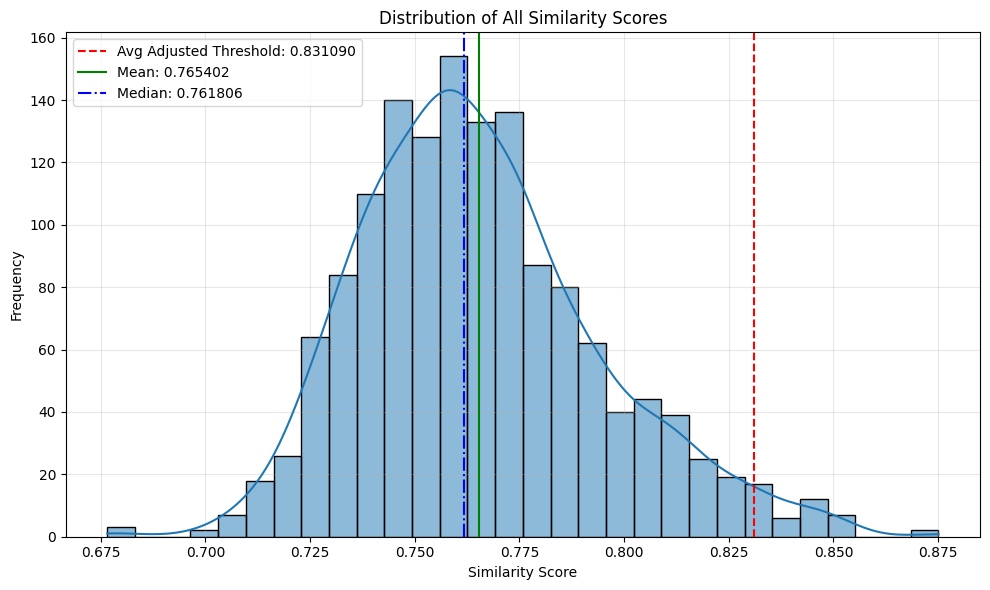

In [25]:
plt.figure(figsize=(10, 6))
sns.histplot(combined_df['similarity_score'], bins=30, kde=True)

# Use dynamic threshold instead of old fixed similarity_threshold
plt.axvline(x=dynamic_threshold, color='r', linestyle='--', label=f'Avg Adjusted Threshold: {dynamic_threshold:.6f}')
plt.axvline(x=metrics_df['avg_similarity'].mean(), color='g', linestyle='-',
            label=f'Mean: {metrics_df["avg_similarity"].mean():.6f}')
plt.axvline(x=metrics_df['median_similarity'].mean(), color='b', linestyle='-.',
            label=f'Median: {metrics_df["median_similarity"].mean():.6f}')

plt.xlabel('Similarity Score')
plt.ylabel('Frequency')
plt.title('Distribution of All Similarity Scores')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

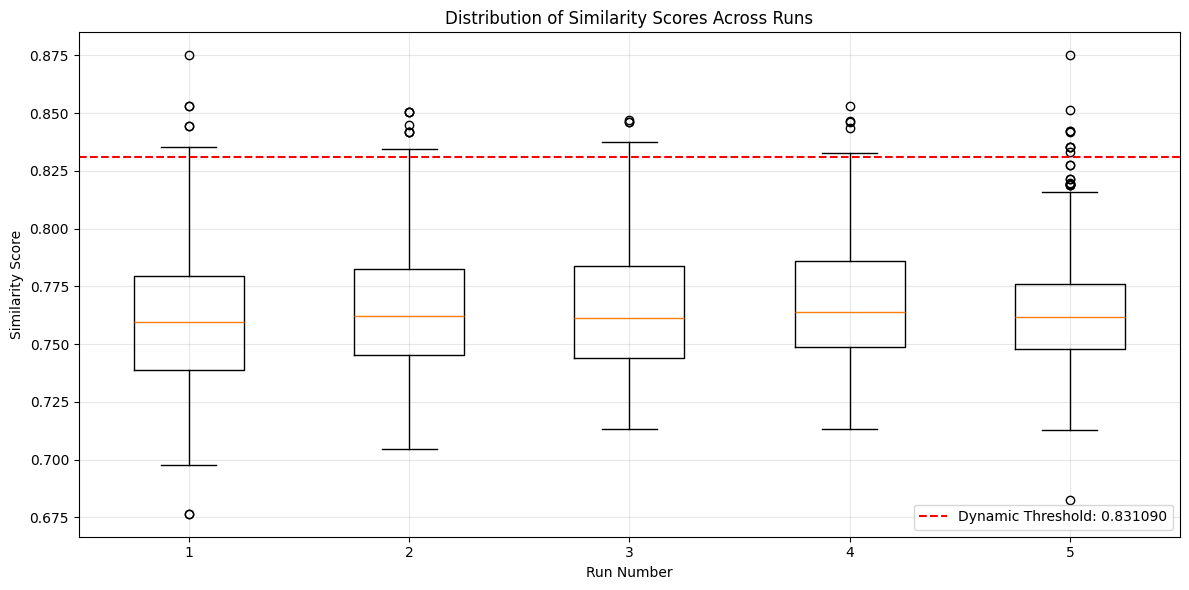

In [26]:
# 3. Box plot of similarity scores across runs
plt.figure(figsize=(12, 6))
boxplot_data = [combined_df[combined_df['run'] == run]['similarity_score'] for run in metrics_df['run']]
plt.boxplot(boxplot_data, tick_labels=metrics_df['run'])  # Updated to tick_labels per Matplotlib 3.9+
plt.axhline(y=dynamic_threshold, color='r', linestyle='--', label=f'Dynamic Threshold: {dynamic_threshold:.6f}')
plt.xlabel('Run Number')
plt.ylabel('Similarity Score')
plt.title('Distribution of Similarity Scores Across Runs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



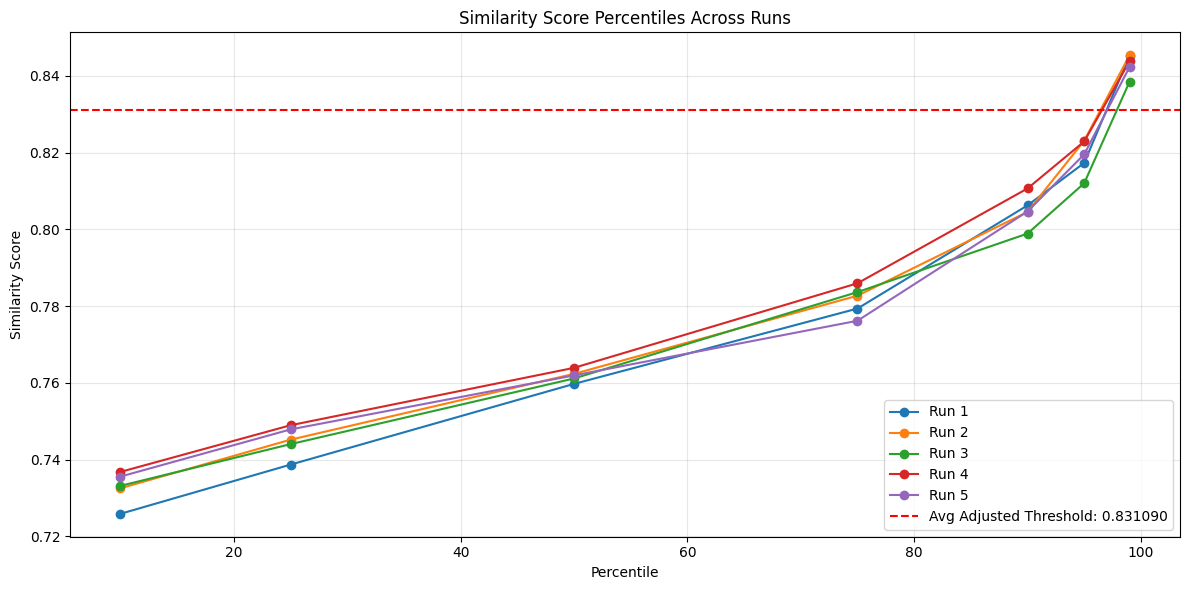

In [27]:
# 4. Percentile analysis
percentiles = [10, 25, 50, 75, 90, 95, 99]
plt.figure(figsize=(12, 6))

for run in metrics_df['run']:
    run_data = combined_df[combined_df['run'] == run]['similarity_score']
    percentile_values = np.percentile(run_data, percentiles)
    plt.plot(percentiles, percentile_values, marker='o', label=f'Run {run}')

# Use dynamic threshold instead of fixed similarity_threshold
plt.axhline(y=dynamic_threshold, color='r', linestyle='--', label=f'Avg Adjusted Threshold: {dynamic_threshold:.6f}')

plt.xlabel('Percentile')
plt.ylabel('Similarity Score')
plt.title('Similarity Score Percentiles Across Runs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
# Extract wrong predictions
wrong_preds = combined_df[combined_df['is_correct'] == False]

# Check the distribution of their similarity scores
print("\n=== SIMILARITY SCORES OF WRONG PREDICTIONS ===")
print(wrong_preds['similarity_score'].describe())

# Lowest and highest scores among wrong predictions
print(f"Lowest wrong score: {wrong_preds['similarity_score'].min():.3f}")
print(f"Highest wrong score: {wrong_preds['similarity_score'].max():.3f}")


=== SIMILARITY SCORES OF WRONG PREDICTIONS ===
count    1403.000000
mean        0.763163
std         0.026024
min         0.676553
25%         0.744572
50%         0.760884
75%         0.778719
max         0.843549
Name: similarity_score, dtype: float64
Lowest wrong score: 0.677
Highest wrong score: 0.844


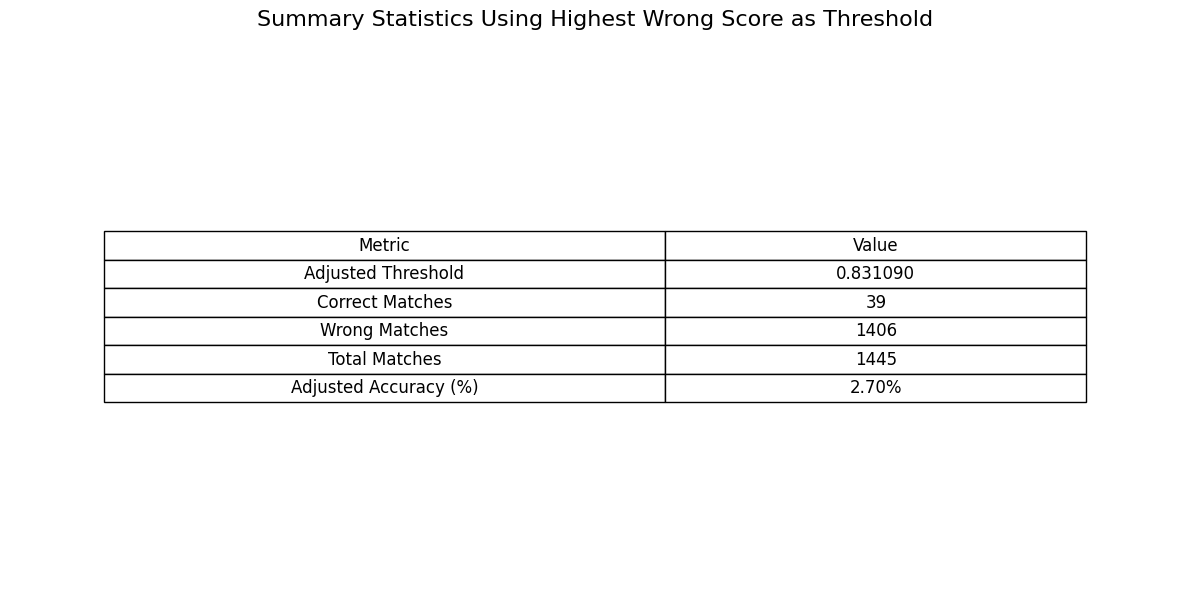

In [30]:
adjusted_threshold = dynamic_threshold

# Recompute correct/wrong matches based on adjusted threshold
combined_df['is_correct_adjusted'] = combined_df['similarity_score'] >= adjusted_threshold

# Count correct and wrong matches
num_correct = combined_df['is_correct_adjusted'].sum()
num_wrong = len(combined_df) - num_correct
accuracy_adjusted = num_correct / len(combined_df) * 100

# Summary table
plt.figure(figsize=(12, 6))
plt.axis('off')
table_data = [
    ['Metric', 'Value'],
    ['Adjusted Threshold', f"{adjusted_threshold:.6f}"],
    ['Correct Matches', f"{num_correct}"],
    ['Wrong Matches', f"{num_wrong}"],
    ['Total Matches', f"{len(combined_df)}"],
    ['Adjusted Accuracy (%)', f"{accuracy_adjusted:.2f}%"]
]

table = plt.table(cellText=table_data, cellLoc='center', loc='center', colWidths=[0.4, 0.3])
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.5)
plt.title('Summary Statistics Using Highest Wrong Score as Threshold', fontsize=16, pad=20)
plt.tight_layout()
plt.show()